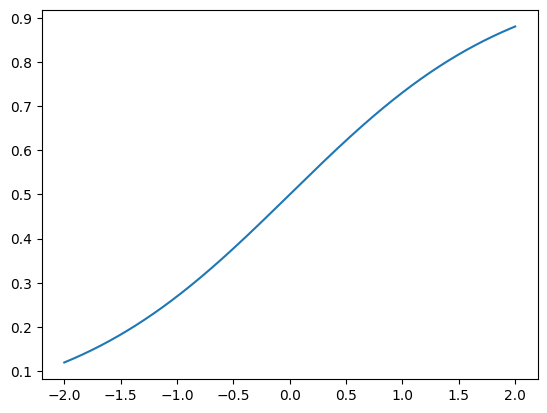

In [1]:
import time

import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(dtype)
torch.set_default_device(device)

x = torch.linspace(-2,2,10000)
y = x.sigmoid()

plt.plot(x.detach().cpu().numpy(),y.detach().cpu().numpy())
plt.show()

In [2]:
epoch = 100000
learning_rate = 2e-3
max_pow = 6
msg_precision = 3
update_interval = 0.5

p = torch.tensor(range(1, max_pow + 1))
xx = x.unsqueeze(-1).pow(p)

loss_fn = torch.nn.MSELoss()

model = torch.nn.Sequential(
    torch.nn.Linear(max_pow, 1),
    torch.nn.Flatten(0, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

with tqdm(total=epoch) as bar:
    update_next = time.time()

    for i in range(1, epoch + 1):
        y_pred = model(xx)
        loss = loss_fn(y_pred, y)

        bar.update(1)

        current_time = time.time()
        if current_time > update_next or i == epoch:
            update_next = current_time + update_interval
            bar.set_postfix(loss=loss.item())

        # 这里按说应该在optimizer上调用zero_grad，但我自己试下来model也不会出问题
        # model.zero_grad()
        optimizer.zero_grad()

        loss.backward()

        # with torch.no_grad():
        #     for param in model.parameters():
        #         param -= learning_rate * param.grad
        optimizer.step()

msg = f"y = {model[0].bias.item():.{msg_precision}f}"
for p, w in enumerate(model[0].weight.tolist()[0], start=1):
    if abs(w) < pow(0.1, msg_precision):
        continue
    msg += " - " if w < 0 else " + "
    msg += f"{abs(w):.{msg_precision}f}"
    msg += f" x^{p}" if p > 1 else " x"
print(msg)

  0%|          | 0/100000 [00:00<?, ?it/s]

y = 0.500 + 0.249 x - 0.019 x^3 + 0.001 x^5


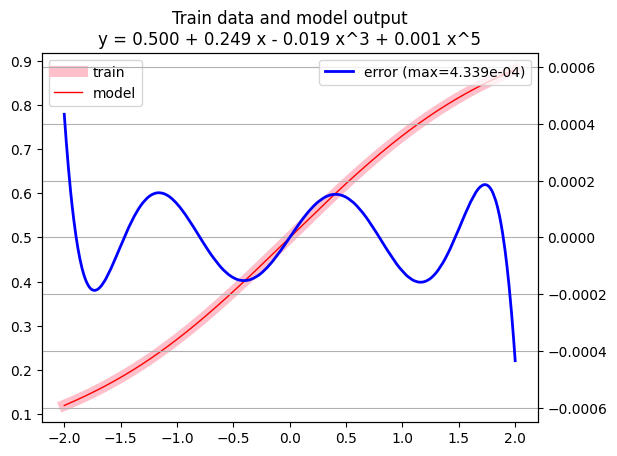

In [3]:
x_plot = x.detach().cpu().numpy()
y_train = y.detach().cpu().numpy()
y_model = model(xx).detach().cpu().numpy()

y_error = y_train - y_model
max_error = float(max(abs(y_error)))

plt.figure()

ax1 = plt.subplot()
ax1.plot(x_plot, y_train, linewidth=8, color='pink', label='train')
ax1.plot(x_plot, y_model, linewidth=1, color='red', label='model')
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(x_plot, y_error, linewidth=2, color='blue', label=f'error (max={max_error:.{msg_precision}e})')
ax2.set_ylim(-max_error*1.5, max_error*1.5)
ax2.legend()

plt.title(
    f"Train data and model output\n"
    f"{msg}"
)
plt.grid(True)
plt.show()